In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import warnings

import geopandas as gpd
import matplotlib.patches as mpatches
from shapely.ops import unary_union

In [6]:
warnings.filterwarnings("ignore", category=FutureWarning, 
                        message=".*force_all_finite.*")

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colours = [(208/255, 28/255, 139/255),
           (241/255, 182/255, 218/255),
           (184/255, 225/255, 134/255),
           (77/255, 172/255, 38/255)]

colours12 = [
    "#a6cee3",
    "#1f78b4",
    "#b2df8a",
    "#33a02c",
    "#fb9a99",
    "#e31a1c",
    "#fdbf6f",
    "#ff7f00",
    "#cab2d6",
    "#6a3d9a",
    "#ffff99",
    "#b15928"
]

In [3]:
def load_pickled_file(filepath):
    with open(filepath, 'rb') as file:
        data = pickle.load(file)
    return data

base_path = 'data/FAO/output_features'

In [11]:
phi_w_list = {}
phi_z_list = {}
phi_zeta_list = {}
alpha_rho_list = {}
beta_rho_list = {}
theta_phi_list = {}

ELBO_full_list = {}

for i in range(27):
    try:
        ## PARAMETERS
        # phi_w
        data = load_pickled_file(f'{base_path}/phi_w/phi_w_{i}.pkl')
        phi_w_list[i] = data
        
        # phi_z
        data = load_pickled_file(f'{base_path}/phi_z/phi_z_{i}.pkl')
        phi_z_list[i] = data
        
        # alpha_rho
        data = load_pickled_file(f'{base_path}/alpha_rho/alpha_rho_{i}.pkl')
        alpha_rho_list[i] = data
        
        # beta_rho
        data = load_pickled_file(f'{base_path}/beta_rho/beta_rho_{i}.pkl')
        beta_rho_list[i] = data
        
        # theta_phi
        data = load_pickled_file(f'{base_path}/theta_phi/theta_phi_{i}.pkl')
        theta_phi_list[i] = data
        
        ## ELBO
        # ELBO_full
        data = load_pickled_file(f'{base_path}/ELBO/ELBO_full_{i}.pkl')
        ELBO_full_list[i] = data
        
    except FileNotFoundError:
        print(f"Skipping iteration {i}: missing files.")
        continue


Skipping iteration 4: missing files.
Skipping iteration 8: missing files.
Skipping iteration 13: missing files.
Skipping iteration 17: missing files.
Skipping iteration 22: missing files.
Skipping iteration 26: missing files.


In [7]:
with open('data/FAO/processed_data/network_to_raw_nodes.pkl', 'rb') as file: 
    network_to_raw_nodes = pickle.load(file) 
    
with open('data/FAO/processed_data/network_to_raw_layers.pkl', 'rb') as file: 
    network_to_raw_layers = pickle.load(file) 
    
countries_names = pd.read_csv('data/FAO/raw_data/fao_trade_nodes.txt', sep='\s+')
countries_names = countries_names.rename(columns={'nodeID': 'Country_Id', 'nodeLabel': 'Country_Name'})
layer_names = pd.read_csv('data/FAO/raw_data/fao_trade_layers.txt', sep='\s+')
layer_names = layer_names.rename(columns={'layerID': 'Layer_Id', 'layerLabel': 'Layer_Name'})

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_72284/3905972896.py:7: SyntaxWarning: invalid escape sequence '\s'
  countries_names = pd.read_csv('data/FAO/raw_data/fao_trade_nodes.txt', sep='\s+')
/tmp/ipykernel_72284/3905972896.py:9: SyntaxWarning: invalid escape sequence '\s'
  layer_names = pd.read_csv('data/FAO/raw_data/fao_trade_layers.txt', sep='\s+')


In [ ]:
# num_nodes = phi_w_list[0][0].shape[0]
# num_layers = phi_z_list[0][0].shape[0]
num_nodes = phi_w_list[0].shape[0]
num_layers = phi_z_list[0].shape[0]

sim = 25

# Map country names
df_output = pd.DataFrame({'Country_Id': range(num_nodes)})
df_output['Country_Id'] = df_output['Country_Id'].map(network_to_raw_nodes)
df_output = pd.merge(df_output, countries_names, on='Country_Id', how='left')

# Compute global groups
global_groups = phi_w_list[sim].argmax(axis=1)
df_output['Global_Group'] = global_groups

# Compute layer groups
layer_groups = phi_z_list[sim].argmax(axis=2)
for k in range(num_layers):
    df_output[layer_names.loc[network_to_raw_layers[k], 'Layer_Name']] = layer_groups[k, :]

map_to_plot = {v: k for k,v in enumerate(df_output['Global_Group'].unique())}
df_output.loc[:,'Global_Group'] = df_output.loc[:,'Global_Group'].map(map_to_plot)

pd.set_option('display.max_rows', None, 'display.max_columns', None)
df_output.sort_values(by='Global_Group')[['Country_Name', 'Global_Group']]

,Country_Name,Global_Group
0,Afghanistan,0
114,Central_African_Republic,0
171,Bhutan,0
150,Rwanda,0
5,Canada,1
10,Denmark,1
2,Austria,1
1,Australia,1
30,Republic_of_Korea,1
29,Poland,1


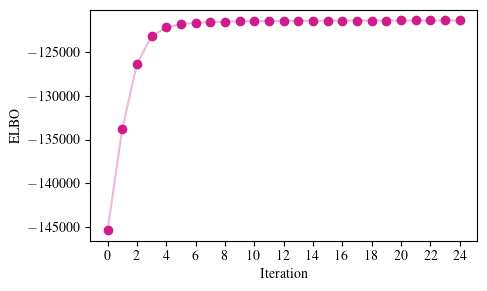

In [147]:
## PLOT OF ELBO
plt.figure(figsize=(5,3))

plt.plot(np.arange(25), ELBO_full_list[sim][:25], color=colours[1])
plt.plot(np.arange(25), ELBO_full_list[sim][:25], 'o', color=colours[0])
plt.xticks(np.arange(0,25,2));
plt.tick_params(axis='both', labelsize=10)

plt.xlabel('Iteration')
plt.ylabel('ELBO');

plt.savefig("data/FAO/plots/ELBO.pdf", dpi=300, bbox_inches="tight")

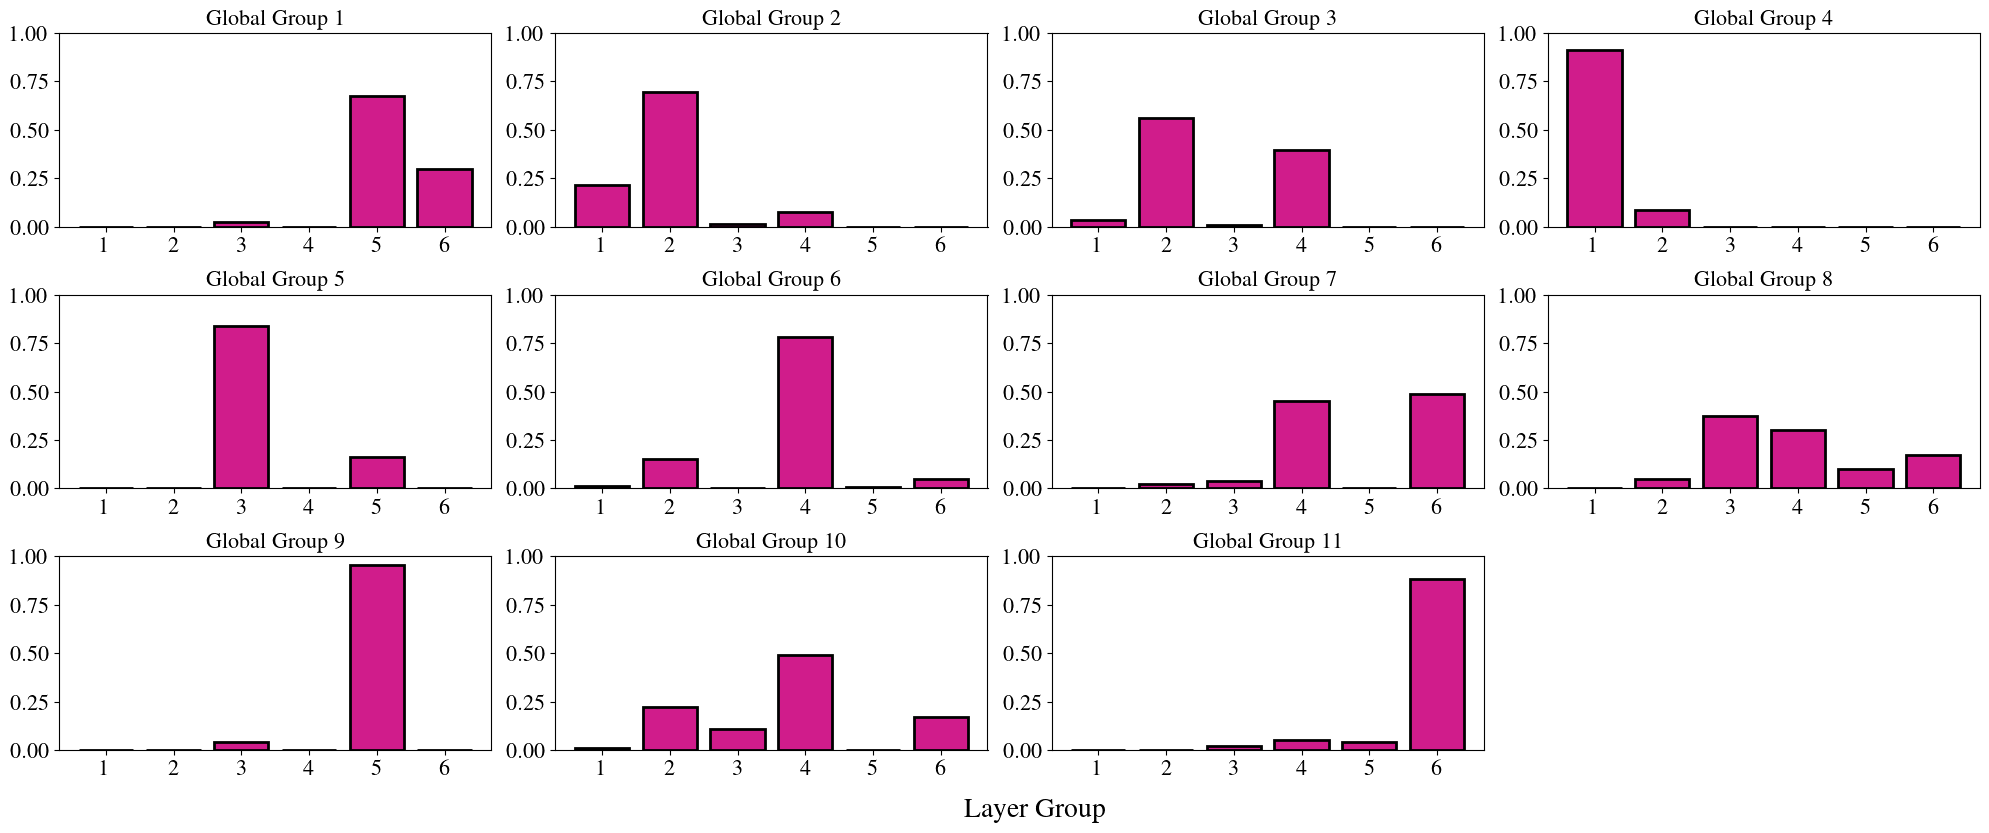

In [31]:

exclude_cols = ['Country_Id', 'Country_Name', 'Global_Group']
numeric_cols = [col for col in df_output.columns if col not in exclude_cols]

# Results dictionary
results = {}

# Get unique Global_Groups
unique_groups = df_output['Global_Group'].unique()
unique_groups.sort()

# Get unique layer groups
num_layer_groups = df_output.drop(columns=exclude_cols).nunique().max()

for idx, group in enumerate(unique_groups):
    # Get counts of layer-level groups in each global group
    group_data = df_output[df_output['Global_Group'] == group]

    # Stack all numeric columns into a single series
    stacked_values = group_data[numeric_cols].values.ravel()

    # Count frequencies
    value_counts = pd.Series(stacked_values).value_counts()

    # Create a series with all possible values, fill missing with 0
    complete_counts = pd.Series(index=range(num_layer_groups), data=0)
    complete_counts.update(value_counts)

    # Sort by index to ensure consistent order
    complete_counts = complete_counts.sort_index()

    results[idx] = complete_counts / complete_counts.sum()
    
# Create subplot grid (2 rows, 5 columns) - 10 global groups
fig, axes = plt.subplots(3, 4, figsize=(20, 8))
# fig.suptitle('Distribution of Layer Groups by Global Group', fontsize=20)

# Flatten axes for easier iteration
axes = axes.ravel()

# For each Global_Group
for idx, group in enumerate(unique_groups):
    # Create histogram
    axes[idx].bar(range(num_layer_groups), results[idx], edgecolor='black', linewidth=2,
                  color=colours[0])
    axes[idx].set_title(f'Global Group {idx + 1}', fontsize=16)
    axes[idx].set_xticks(range(num_layer_groups))
    axes[idx].set_xticklabels(range(1, num_layer_groups + 1))   
    
    # Set consistent y-axis limits across all subplots
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='both', labelsize=16);  
    
fig.delaxes(axes[-1])    
# fig.text(-0.01, 0.5, "Proportion of Global Group", va='center', ha='center', rotation=90, fontsize=20, fontweight='bold')
fig.text(0.52, -0.02, "Layer Group", va='center', ha='center', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('data/FAO/plots/layer_group_proportion_features.pdf', dpi=300, bbox_inches="tight")

In [166]:
def get_country_names():
    """
    Get a sorted list of all country names in the dataset.
    
    Returns:
    list: Sorted list of country names
    """
    # Load Natural Earth data at 1:110m scale
    world = gpd.read_file('data/FAO/raw_data/map_sub_units/ne_10m_admin_0_map_subunits.shp')

    return sorted(world['NAME_LONG'].tolist())

# Extract country names
map_country_names = get_country_names()

def create_colored_map(country_groups, colors, group_labels, title="World Map"):
    """
    Create a world map with countries colored according to specified groupings.
    Uses Natural Earth Data which has more comprehensive country coverage.
    """
    # Load Natural Earth data at 1:110m scale    
    world = gpd.read_file('data/FAO/raw_data/map_sub_units/ne_10m_admin_0_map_subunits.shp')

    ## Manual merging of certain countries
    # Italy
    # 97, 275, 277, 279, 340
    geom1 = world.loc[97, 'geometry']
    geom2 = world.loc[275, 'geometry']
    geom3 = world.loc[277, 'geometry']
    geom4 = world.loc[279, 'geometry']
    geom5 = world.loc[340, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3, geom4, geom5])
    merged_geometry = unary_union(gdf)
    world.at[97, 'geometry'] = merged_geometry
    world.at[97, 'NAME_LONG'] = 'Italy'
    world = world.drop(index=[275, 277, 279, 340])
    
    # Russia
    # 50, 55, 156, 192
    geom1 = world.loc[50, 'geometry']
    geom2 = world.loc[55, 'geometry']
    geom3 = world.loc[156, 'geometry']
    geom4 = world.loc[192, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3, geom4])
    merged_geometry = unary_union(gdf)
    world.at[50, 'geometry'] = merged_geometry
    world.at[50, 'NAME_LONG'] = 'Russia'
    world = world.drop(index=[55, 156, 192])
    
    # England, Scotland, Wales, Northern Island
    geom1 = world.loc[85, 'geometry']
    geom2 = world.loc[194, 'geometry']
    geom3 = world.loc[195, 'geometry']
    geom4 = world.loc[196, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3, geom4])
    merged_geometry = unary_union(gdf)
    world.at[194, 'geometry'] = merged_geometry
    world.at[194, 'NAME_LONG'] = 'United Kingdom'
    world = world.drop(index=[85, 195, 196])
    
    # Belgium
    # 64, 65, 197
    geom1 = world.loc[64, 'geometry']
    geom2 = world.loc[65, 'geometry']
    geom3 = world.loc[197, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3])
    merged_geometry = unary_union(gdf)
    world.at[64, 'geometry'] = merged_geometry
    world.at[64, 'NAME_LONG'] = 'Belgium'
    world = world.drop(index=[65, 197])

    # Syria 
    geom1 = world.loc[21, 'geometry']
    geom2 = world.loc[39, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2])
    merged_geometry = unary_union(gdf)
    world.at[21, 'geometry'] = merged_geometry
    world.at[21, 'NAME_LONG'] = 'Syria'
    world = world.drop(index=39)
    
    # Trinidad and Tobago 
    geom1 = world.loc[232, 'geometry']
    geom2 = world.loc[233, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2])
    merged_geometry = unary_union(gdf)
    world.at[232, 'geometry'] = merged_geometry
    world.at[232, 'NAME_LONG'] = 'Trinidad and Tobago'
    world = world.drop(index=233)
    
    # New Zealand (South I., North I.) 
    geom1 = world.loc[347, 'geometry']
    geom2 = world.loc[348, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2])
    merged_geometry = unary_union(gdf)
    world.at[347, 'geometry'] = merged_geometry
    world.at[347, 'NAME_LONG'] = 'New Zealand'
    world = world.drop(index=348)
        
    # US, Alaska, Hawaii (South I., North I.) 
    geom1 = world.loc[170, 'geometry']
    geom2 = world.loc[182, 'geometry']
    geom3 = world.loc[292, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3])
    merged_geometry = unary_union(gdf)
    world.at[170, 'geometry'] = merged_geometry
    world = world.drop(index=[182, 292])
    
    # Japan
    # 216, 217, 218, 220, 221, 293, 294, 295
    geom1 = world.loc[216, 'geometry']
    geom2 = world.loc[217, 'geometry']
    geom3 = world.loc[218, 'geometry']
    geom4 = world.loc[220, 'geometry']
    geom5 = world.loc[221, 'geometry']
    geom6 = world.loc[293, 'geometry']
    geom7 = world.loc[294, 'geometry']
    geom8 = world.loc[295, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3, geom4, geom5, geom6, geom7, geom8])
    merged_geometry = unary_union(gdf)
    world.at[216, 'geometry'] = merged_geometry
    world = world.drop(index=[217, 218, 220, 221, 293, 294, 295])
    
    # South Korea
    # 26, 188, 219, 297, 298, 299, 358
    geom1 = world.loc[26, 'geometry']
    geom2 = world.loc[188, 'geometry']
    geom3 = world.loc[219, 'geometry']
    geom4 = world.loc[297, 'geometry']
    geom5 = world.loc[298, 'geometry']
    geom6 = world.loc[299, 'geometry']
    geom7 = world.loc[358, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2, geom3, geom4, geom5, geom6, geom7])
    merged_geometry = unary_union(gdf)
    world.at[26, 'geometry'] = merged_geometry
    world.at[26, 'NAME_LONG'] = 'South Korea'
    world = world.drop(index=[188, 219, 297, 298, 299, 358])
    
    # North Korea
    geom1 = world.loc[27, 'geometry']
    geom2 = world.loc[157, 'geometry']
    gdf = gpd.GeoSeries([geom1, geom2])
    merged_geometry = unary_union(gdf)
    world.at[27, 'geometry'] = merged_geometry
    world.at[27, 'NAME_LONG'] = 'North Korea'
    world = world.drop(index=157)
    
    # Create a color mapping for each country
    world['color'] = 'white'  # Default color
    for country, group in country_groups.items():
        # Match country names (case-insensitive)
        
        # matching_rows = world['NAME_LONG'].str.lower() == country.lower()
        # print(f"Country: {country}, Matches found: {matching_rows.sum()}")
        
        world.loc[world['NAME_LONG'].str.lower() == country.lower(), 'color'] = colors[group]
    
        
        # matching_rows = world['NAME_LONG'].str.lower() == country.lower()
        # # Check if no matches or multiple matches exist
        # if matching_rows.sum() != 1:
        #     print(f"Issue with country: {country} - Matches found: {matching_rows.sum()}")
        #     continue  # Skip problematic entries to prevent the ValueError
    
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Plot the map
    world.plot(color=world['color'], 
              ax=ax,
              edgecolor='black',
              linewidth=0.5)
    
    # Create legend patches
    legend_patches = []
    for color, label in zip(colors, group_labels):
        patch = mpatches.Patch(color=color, label=label)
        legend_patches.append(patch)
    
    # Add a patch for uncolored countries
    legend_patches.append(mpatches.Patch(color='white', label='Other Countries'))
    
    # Add legend
    ax.legend(handles=legend_patches, 
             loc='lower left',
             bbox_to_anchor=(0.05, 0.15),
             fontsize=15)
    
    # Remove axes
    ax.axis('off')
    
    # Add title
    plt.title(title, fontsize=20, pad=20)
    
    return fig

In [9]:
world = gpd.read_file('data/FAO/raw_data/map_sub_units/ne_10m_admin_0_map_subunits.shp')

world[world['NAME'].isin(['England', 'Scotland', 'Wales', 'N. Ireland'])] # 85, 194, 195, 196
world[world['NAME'].isin(['Trinidad', 'Tobago'])] # 232, 233
world[world['NAME'].isin(['North I.', 'South I.'])] # 347 348
world[world['NAME'].isin(['United States of America', 'Alaska', 'Hawaii'])] # 170, 182, 292
world.loc[world['SOVEREIGNT'] == 'Japan', 'NAME'] # 216, 217, 218, 220, 221, 293, 294, 295
world.loc[world['SOVEREIGNT'] == 'Kazakhstan', 'NAME'] # 26, 188, 219, 297, 298, 299, 358 
world.loc[world['SOVEREIGNT'] == 'Russia', 'NAME'] # 50, 55, 156, 192
world.loc[world['SOVEREIGNT'] == 'Italy', 'NAME'] # 97, 275, 277, 279, 340
world.loc[world['SOVEREIGNT'] == 'Syria', 'NAME'] # 21, 39
world.loc[world['SOVEREIGNT'] == 'Belgium', 'NAME'] # 64, 65, 197

64      Flemish
65      Walloon
197    Brussels
Name: NAME, dtype: object

In [157]:
country_mapping = {
        'Australia': 'Australia',
        'Austria': 'Austria',
        'Belgium': 'Belgium',
        'Brazil': 'Brazil',
        'Canada': 'Canada',
        'China': 'China',
        'China,_Hong_Kong_SAR': 'Hong Kong',
        'China,_mainland': 'China',
        'China,_Taiwan_Province_of': 'Taiwan',
        'Denmark': 'Denmark',
        'Egypt': 'Egypt',
        'Finland': 'Finland',
        'France': 'France',
        'Germany': 'Germany',
        'Guatemala': 'Guatemala',
        'India': 'India',
        'Indonesia': 'Indonesia',
        'Iran_(Islamic_Republic_of)': 'Iran',
        'Iraq': 'Iraq',
        'Ireland': 'Ireland',
        'Italy': 'Italy',
        'Japan': 'Japan',
        'Kazakhstan': 'Kazakhstan',
        'Lebanon': 'Lebanon',
        'Malaysia': 'Malaysia',
        'Netherlands': 'Netherlands',
        'Pakistan': 'Pakistan',
        'Philippines': 'Philippines',
        'Poland': 'Poland',
        'Republic_of_Korea': 'South Korea',
        'Russian_Federation': 'Russia',
        'Saudi_Arabia': 'Saudi Arabia',
        'Singapore': 'Singapore',
        'Spain': 'Spain',
        'Sweden': 'Sweden',
        'Switzerland': 'Switzerland',
        'Tajikistan': 'Tajikistan',
        'Thailand': 'Thailand',
        'Turkey': 'Turkey',
        'Turkmenistan': 'Turkmenistan',
        'United_Arab_Emirates': 'United Arab Emirates',
        'United_States_of_America': 'United States of America',
        'Uzbekistan': 'Uzbekistan',
        'Viet_Nam': 'Vietnam',
        'Albania': 'Albania',
        'Argentina': 'Argentina',
        'Bahamas': 'Bahamas',
        'Bosnia_and_Herzegovina': 'Fed. of Bos. & Herz.',
        'Bulgaria': 'Bulgaria',
        'Cabo_Verde': 'Cabo Verde',
        'Cameroon': 'Cameroon',
        'Colombia': 'Colombia',
        'Comoros': 'Comoros',
        'Costa_Rica': 'Costa Rica',
        "CÃ´te_d'Ivoire": "Côte d'Ivoire",
        'Croatia': 'Croatia',
        'Cuba': 'Cuba',
        'Cyprus': 'Cyprus',
        'Czech_Republic': 'Czechia',
        'Dominica': 'Dominica',
        'Dominican_Republic': 'Dominican Rep.',
        'Ecuador': 'Ecuador',
        'Ethiopia': 'Ethiopia',
        'Greece': 'Greece',
        'Hungary': 'Hungary',
        'Israel': 'Israel',
        'Kenya': 'Kenya',
        'Kyrgyzstan': 'Kyrgyzstan',
        'Lithuania': 'Lithuania',
        'Luxembourg': 'Luxembourg',
        'Malawi': 'Malawi',
        'Mexico': 'Mexico',
        'Montenegro': 'Montenegro',
        'Morocco': 'Morocco',
        'Nicaragua': 'Nicaragua',
        'Norway': 'Norway',
        'Panama': 'Panama',
        'Portugal': 'Portugal',
        'Republic_of_Moldova': 'Moldova',
        'Romania': 'Romania',
        'Slovakia': 'Slovakia',
        'Slovenia': 'Slovenia',
        'Syrian_Arab_Republic': 'Syria',
        'The_former_Yugoslav_Republic_of_Macedonia': 'North Macedonia',
        'Tunisia': 'Tunisia',
        'Uganda': 'Uganda',
        'Venezuela_(Bolivarian_Republic_of)': 'Venezuela',
        'Bolivia_(Plurinational_State_of)': 'Bolivia',
        'Chile': 'Chile',
        'El_Salvador': 'El Salvador',
        'Estonia': 'Estonia',
        'Fiji': 'Fiji',
        'Georgia': 'Georgia',
        'Honduras': 'Honduras',
        'Iceland': 'Iceland',
        'Jamaica': 'Jamaica',
        'Madagascar': 'Madagascar',
        'Papua_New_Guinea': 'Papua New Guinea',
        'Paraguay': 'Paraguay',
        'Peru': 'Peru',
        'South_Africa': 'South Africa',
        'Sri_Lanka': 'Sri Lanka',
        'Sudan_(former)': 'Sudan',
        'United_Republic_of_Tanzania': 'Tanzania',
        'Uruguay': 'Uruguay',
        'Zambia': 'Zambia',
        'Armenia': 'Armenia',
        'Belarus': 'Belarus',
        'Central_African_Republic': 'Central African Rep.',
        'Ghana': 'Ghana',
        'Guyana': 'Guyana',
        'Latvia': 'Latvia',
        'Mali': 'Mali',
        'Nauru': 'Nauru',
        'Oman': 'Oman',
        'Sierra_Leone': 'Sierra Leone',
        'Aruba': 'Aruba',
        'Barbados': 'Barbados',
        'Suriname': 'Suriname',
        'American_Samoa': 'American Samoa',
        'Azerbaijan': 'Azerbaijan',
        'Bahrain': 'Bahrain',
        'Bangladesh': 'Bangladesh',
        'Belize': 'Belize',
        'Bermuda': 'Bermuda',
        'Botswana': 'Botswana',
        'Cambodia': 'Cambodia',
        'China,_Macao_SAR': 'Macao',
        "Democratic_People's_Republic_of_Korea": 'North Korea',
        'Democratic_Republic_of_the_Congo': 'Dem. Rep. Congo',
        'Djibouti': 'Djibouti',
        'Jordan': 'Jordan',
        "Lao_People's_Democratic_Republic": 'Laos',
        'Malta': 'Malta',
        'Marshall_Islands': 'Marshall Is.',
        'Mongolia': 'Mongolia',
        'Mozambique': 'Mozambique',
        'Myanmar': 'Myanmar',
        'Namibia': 'Namibia',
        'Nepal': 'Nepal',
        'New_Caledonia': 'New Caledonia',
        'Niger': 'Niger',
        'Qatar': 'Qatar',
        'Rwanda': 'Rwanda',
        'Saint_Lucia': 'Saint Lucia',
        'Samoa': 'Samoa',
        'Solomon_Islands': 'Solomon Is.',
        'Timor-Leste': 'Timor-Leste',
        'Vanuatu': 'Vanuatu',
        'Yemen': 'Yemen',
        'Zimbabwe': 'Zimbabwe',
        'Algeria': 'Algeria',
        'Burkina_Faso': 'Burkina Faso',
        'Grenada': 'Grenada',
        'Kuwait': 'Kuwait',
        'Togo': 'Togo',
        'Falkland_Islands_(Malvinas)': 'Falkland Is.',
        'Saint_Vincent_and_the_Grenadines': 'St. Vin. and Gren.',
        'Angola': 'Angola',
        'Burundi': 'Burundi',
        'French_Polynesia': 'Fr. Polynesia',
        'Gabon': 'Gabon',
        'Liberia': 'Liberia',
        'Senegal': 'Senegal',
        'British_Virgin_Islands': 'British Virgin Is.',
        'Cook_Islands': 'Cook Is.',
        'Guinea-Bissau': 'Guinea-Bissau',
        'Libya': 'Libya',
        'Micronesia_(Federated_States_of)': 'Micronesia',
        'Mauritania': 'Mauritania',
        'Andorra': 'Andorra',
        'Ukraine': 'Ukraine',
        'United_Kingdom': 'United Kingdom',  # Complex as split into England, Scotland, Wales
        'Trinidad_and_Tobago': 'Trinidad and Tobago',  # Split into Trinidad and Tobago
        'New_Zealand': 'New Zealand'  # Split into North I. and South I.
        # 'Netherlands_Antilles': None,  # Dissolved
        # 'New_Zealand': None,  # Split into North I. and South I.
        # 'Sao_Tome_and_Principe': None,  # Split into São Tomé and Principe
        # 'Unspecified': None
    }

In [158]:
countries_on_map = countries_names.loc[network_to_raw_nodes.values()]['Country_Name'].map(country_mapping).dropna()
df_output_plot = df_output[df_output['Country_Name'].isin(country_mapping.keys())]
df_output_plot.loc[:,'Country_Name'] = df_output_plot.loc[:,'Country_Name'].map(country_mapping)

country_groups_plot = dict(df_output_plot[['Country_Name', 'Global_Group']].values)

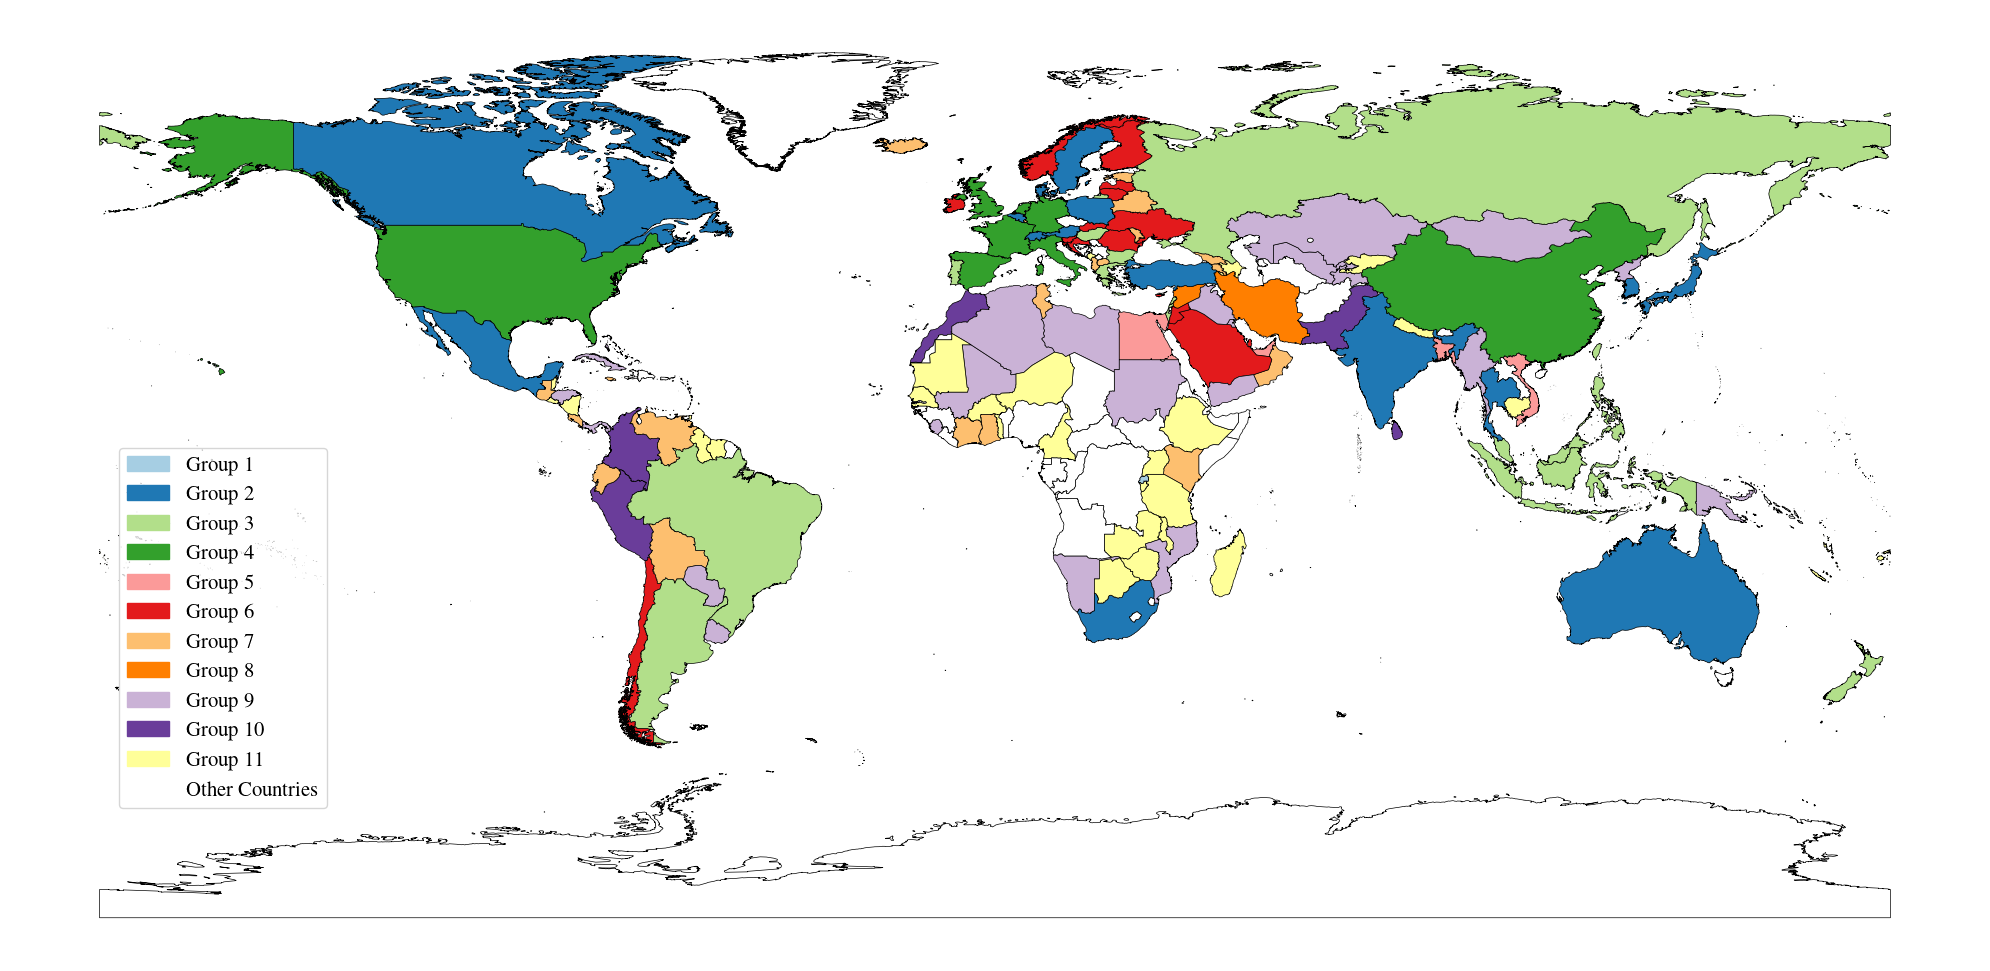

In [168]:
# Define labels for each group
group_labels = [f"Group {k+1}" for k in range(11)]

# Create and show the map
fig = create_colored_map(country_groups_plot, colours12[:11], group_labels, "")
plt.tight_layout()
plt.savefig('data/FAO/plots/world_map.pdf', dpi=300, bbox_inches="tight")

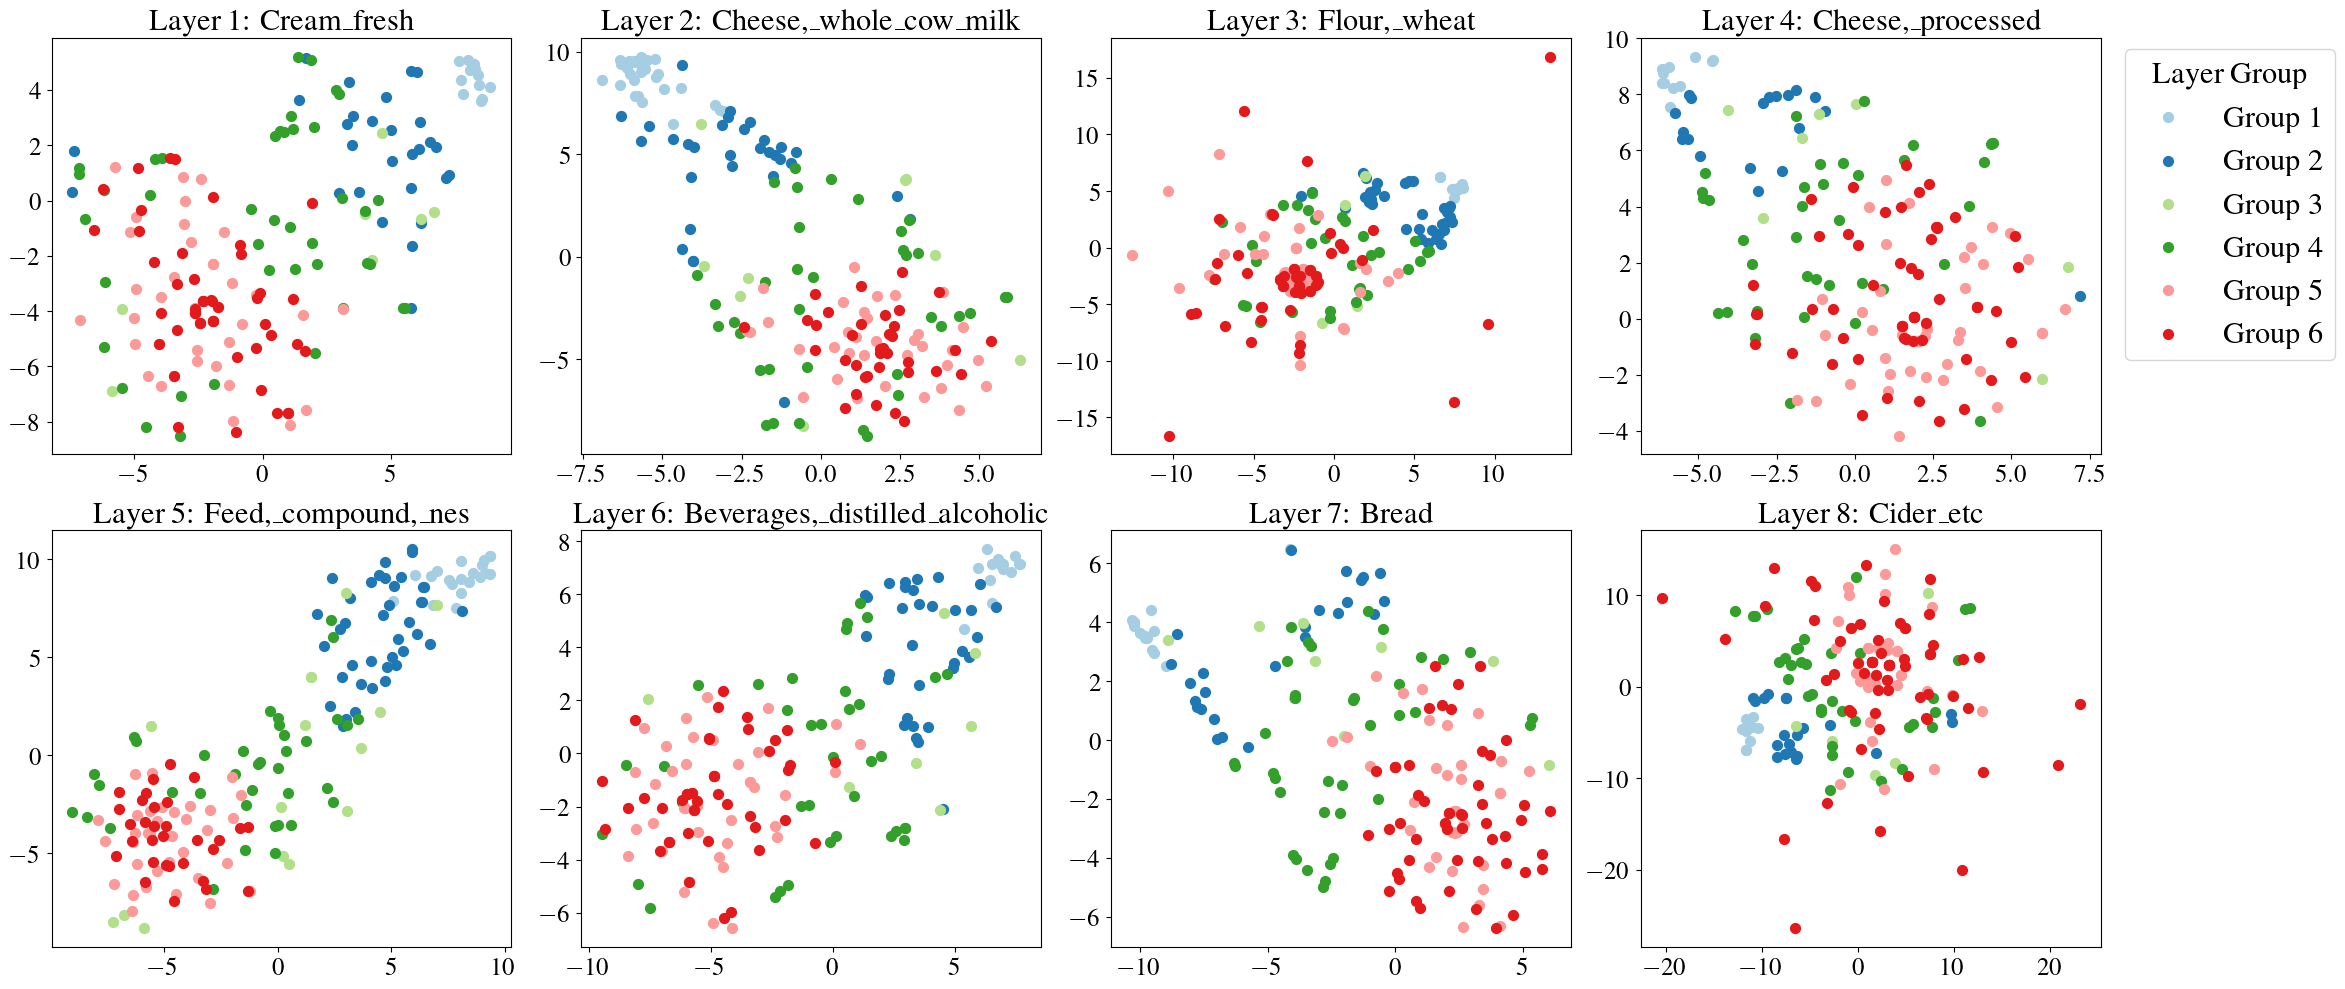

In [150]:
# LAYERS 1-8: LAYER COLOUR

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_graph_tsne(adj_matrix, group_assignments, colors):
    tsne = TSNE(n_components=2, 
                random_state=42, 
                perplexity=min(30, adj_matrix.shape[0] - 1),
                max_iter=1000,
                init='pca')
    
    if not isinstance(adj_matrix, np.ndarray):
        adj_matrix = adj_matrix.todense()
        
    return tsne.fit_transform(adj_matrix)

# Create the subplots
# fig, axs = plt.subplots(3, 3, figsize=(25, 20))
fig, axs = plt.subplots(2, 4, figsize=(25, 10))
axs = axs.flatten()  # Flatten the 2D array of axes into 1D
layers_to_plot = np.arange(8)

numeric_cols = df_output.drop(columns=['Country_Id', 'Country_Name', 'Global_Group']).columns
adj_tensor = np.load('data/FAO/processed_data/adjacency_tensor.npy')

# Store legends for each row
row1_handles, row1_labels = None, None

# Generate embeddings for each layer
for i, layer in enumerate(layers_to_plot):
    layer_groups = df_output.loc[:,numeric_cols[layer]]
    embedding_layer = visualize_graph_tsne(adj_tensor[layer], layer_groups, colours12)
    
    # Plot layer groups
    for group in np.unique(layer_groups):
        mask = layer_groups == group
        scatter = axs[i].scatter(embedding_layer[mask, 0], 
                               embedding_layer[mask, 1],
                               c=[colours12[group]],
                               alpha=1,
                               label=f'Group {group + 1}',
                            #    edgecolors=(0, 0, 0, 0.01),
                            #    edgecolors='black',
                            #    linewidth=0.001,
                               s=50)
        axs[i].tick_params(labelsize=18)
    
    axs[i].set_title(f'Layer {layer + 1}: {numeric_cols[layer]}', fontsize=22)
    
    # Store handles and labels from first plot for legend
    if i == 0:
        row1_handles, row1_labels = axs[0].get_legend_handles_labels()

# Add legend
fig.legend(row1_handles, row1_labels, 
          bbox_to_anchor=(0.95, 0.96),
          title="Layer Group",
          title_fontsize=22,
          fontsize=22)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.savefig('data/FAO/plots/tsne_layer_groups_1_8.pdf', dpi=300, bbox_inches="tight")

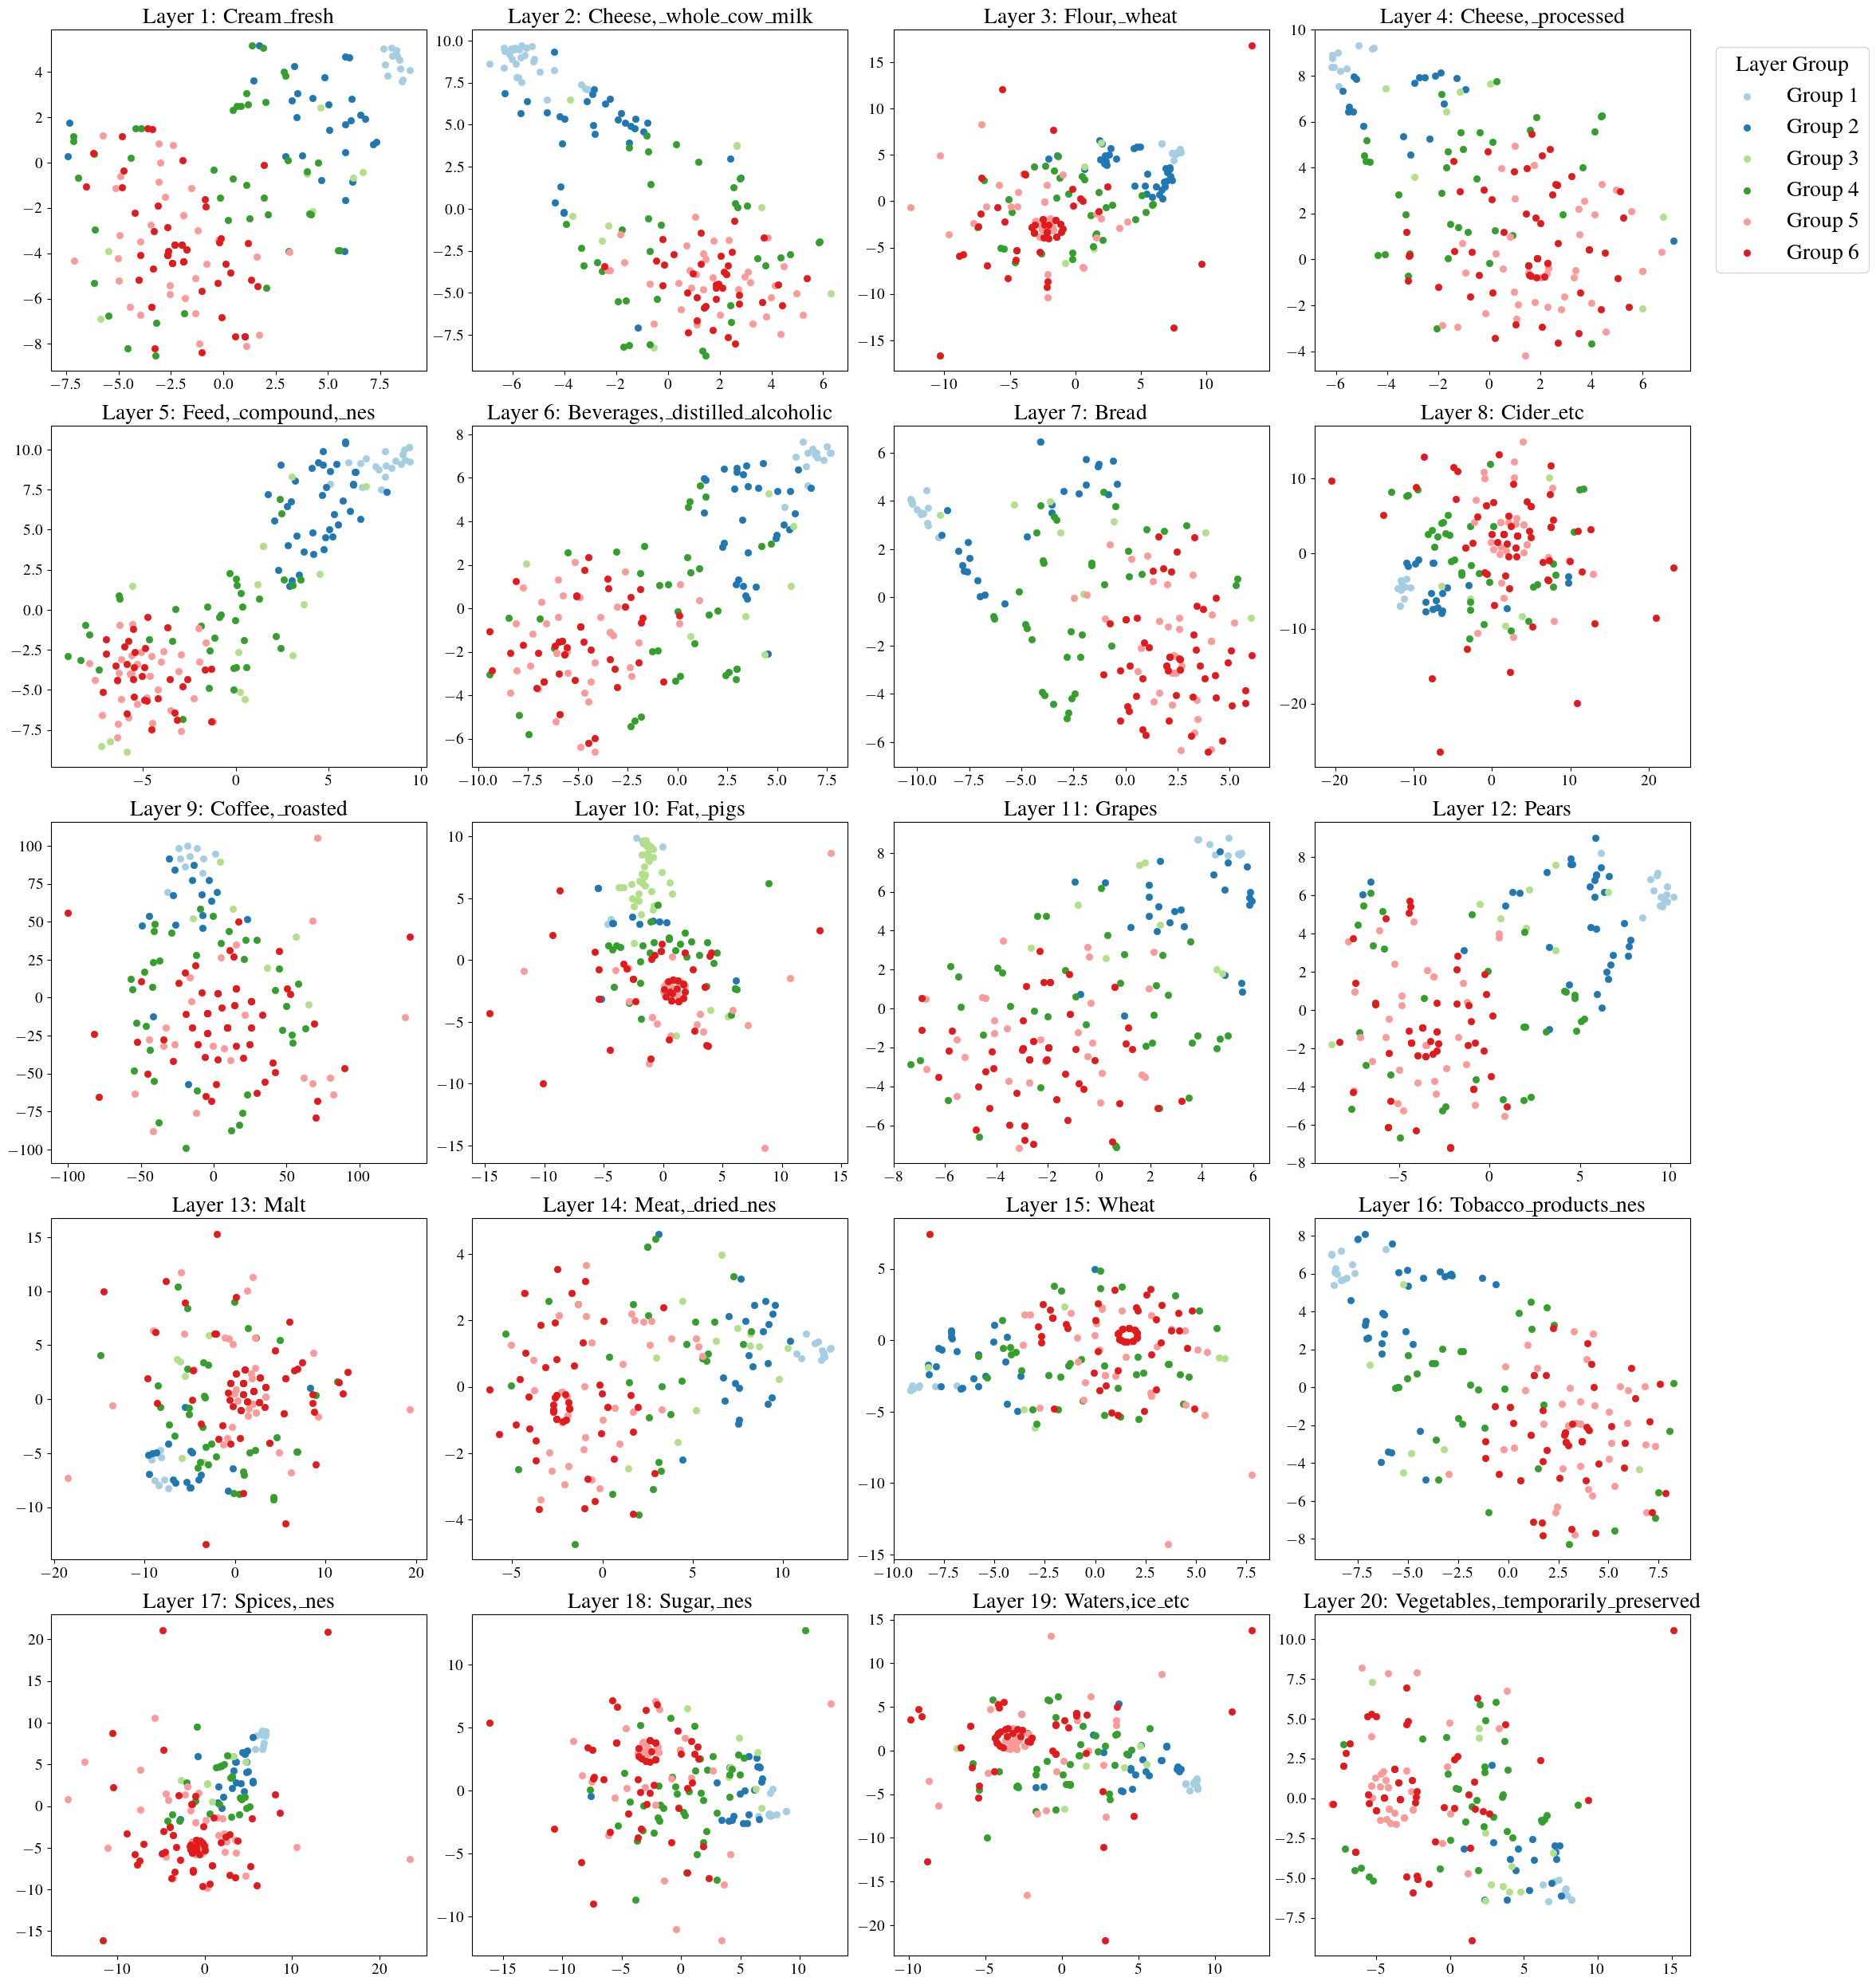

In [131]:
# ALL LAYERS: LAYER COLOUR

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_graph_tsne(adj_matrix, group_assignments, colors):
    tsne = TSNE(n_components=2, 
                random_state=42, 
                perplexity=min(30, adj_matrix.shape[0] - 1),
                max_iter=1000,
                init='pca')
    
    if not isinstance(adj_matrix, np.ndarray):
        adj_matrix = adj_matrix.todense()
        
    return tsne.fit_transform(adj_matrix)

# Create the subplots
fig, axs = plt.subplots(5, 4, figsize=(25, 25))
axs = axs.flatten()  # Flatten the 2D array of axes into 1D
layers_to_plot = np.arange(20)

numeric_cols = df_output.drop(columns=['Country_Id', 'Country_Name', 'Global_Group']).columns
adj_tensor = np.load('data/FAO/processed_data/adjacency_tensor.npy')

# Store legends for each row
row1_handles, row1_labels = None, None

# Generate embeddings for each layer
for i, layer in enumerate(layers_to_plot):
    layer_groups = df_output.loc[:,numeric_cols[layer]]
    embedding_layer = visualize_graph_tsne(adj_tensor[layer], layer_groups, colours12)
    
    # Plot layer groups
    for group in np.unique(layer_groups):
        mask = layer_groups == group
        scatter = axs[i].scatter(embedding_layer[mask, 0], 
                               embedding_layer[mask, 1],
                               c=[colours12[group]],
                               alpha=1,
                               label=f'Group {group + 1}',
                            #    edgecolors='black?',
                               linewidth=0.5)
        axs[i].tick_params(labelsize=14)
    
    axs[i].set_title(f'Layer {layer + 1}: {numeric_cols[layer]}', fontsize=20)
    
    # Store handles and labels from first plot for legend
    if i == 0:
        row1_handles, row1_labels = axs[0].get_legend_handles_labels()

# Add legend
fig.legend(row1_handles, row1_labels, 
          bbox_to_anchor=(0.945, 0.98),
          title="Layer Group",
          title_fontsize=20,
          fontsize=20)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.savefig('data/FAO/plots/tsne_layer_groups.pdf', dpi=300, bbox_inches="tight")